In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

current_dir = os.getcwd()

project_root = os.path.abspath(os.path.join(current_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from problems import *
from scipy.spatial import cKDTree

In [3]:
#-- PARAMETERS --#

N = 6400
K = 25
l = 4
kappa = 3
delta = 1e-5
l_grad = 5
K_grad = 30

np.random.seed(0)

In [4]:
#-- GEOMETRY --#

theta, phi = sp.symbols('theta phi', real=True)
R = 2.0
r = 1.0

x_sym = (R + r * sp.cos(theta)) * sp.cos(phi)
y_sym = (R + r * sp.cos(theta)) * sp.sin(phi)
z_sym = r * sp.sin(theta)

manifold = Manifold([theta, phi], [x_sym, y_sym, z_sym])
manifold.compute()

theta_range = (0, 2*np.pi)
phi_range = (0, np.pi)
# phi_range = (np.pi / 9, 8 * np.pi / 9)

phi_min = phi_range[0]
phi_max = phi_range[1]

num_boundary = 2 * int(np.round(np.sqrt(2*r/R)*np.sqrt(N)))
# num_boundary = 2 * int(np.round(np.sqrt(2*r*9/(R*7))*np.sqrt(N))) # TODO: adaptive code
num_interior = N - num_boundary

manifold.sample([theta_range, phi_range], num_interior)

# sample boundary

x_sym_left = (R + r * sp.cos(theta)) * sp.cos(phi_min)
y_sym_left = (R + r * sp.cos(theta)) * sp.sin(phi_min)

boundary_left = Manifold([theta], [x_sym_left, y_sym_left, z_sym])
boundary_left.sample([theta_range], num_boundary // 2)

x_sym_right = (R + r * sp.cos(theta)) * sp.cos(phi_max)
y_sym_right = (R + r * sp.cos(theta)) * sp.sin(phi_max)

boundary_right = Manifold([theta], [x_sym_right, y_sym_right, z_sym])
boundary_right.sample([theta_range], num_boundary // 2)

manifold.params = np.vstack([
    manifold.params,
    np.insert(boundary_left.params, 1, values=phi_min, axis=1),
    np.insert(boundary_right.params, 1, values=phi_max, axis=1)
])

manifold.points = np.vstack([
    manifold.points,
    boundary_left.points,
    boundary_right.points
])

id_interior = np.arange(num_interior)
id_boundary = np.arange(num_interior, N)

In [5]:
#-- MANUFACTURED SOLUTION --#

u_sym = sp.sin(theta) * sp.cos(phi + sp.pi/4)

u_lap_sym = manifold.get_laplacian(u_sym)
u_grad_sym = manifold.get_gradient(u_sym)
f_sym = -u_lap_sym

tt = manifold.params[:, 0]
pp = manifold.params[:, 1]

f_func = sp.lambdify((theta, phi), f_sym, 'numpy')
f_vals = f_func(tt, pp)

u_func = sp.lambdify((theta, phi), u_sym, 'numpy')
u_vals = u_func(tt, pp)

u_lap_func = sp.lambdify((theta, phi), u_lap_sym, 'numpy')
u_lap_vals = u_lap_func(tt, pp)

u_grad_func = sp.lambdify((theta, phi), u_grad_sym, 'numpy')
u_grad_vals = u_grad_func(tt, pp) # shape: (n, 1, N)

u_grad_vals_boundary = u_grad_vals.squeeze()[:, id_boundary].T # shape: (num_boundary, n)

# outward normal at each boundary point
n_vecs = np.zeros((num_boundary, manifold.n)) # shape: (num_boundary, n)

for i in range(num_boundary):
    n_vecs[i, :] = [0.0, -1.0, 0.0]

g_vals = u_vals[id_boundary] + np.sum(n_vecs * u_grad_vals_boundary, axis=1) # shape: (num_boundary)

In [6]:
from src import *

good_weights_list = []
pos_weights_list = []
ill_weights_list = [] # ratio < 1.0
both_weights_list = []
fixed_weights_list = []

#-- LAPLACIAN --#

L = np.zeros((num_interior, N))
tree_full = cKDTree(manifold.points)

bad_count = 0
for i, i_id in enumerate(id_interior):
    # auto K
    K_current = K
    max_K_retries = 15

    K_retries = 0

    best_ratio = -1.0
    best_weights = None
    best_stencil_ids = None

    while True:
        _, stencil_ids = tree_full.query(manifold.points[i_id], K_current)

        weights_lap = get_operator_weights(
            stencil=manifold.points[stencil_ids],
            tangent_basis=manifold.get_local_basis(manifold.params[i])[0],
            operator='lap',
            kappa=kappa,
            l=l,
            delta=delta,
        ) # shape: (1, K)

        if K_current == K:
            initial_weights = weights_lap.copy()
            initial_stencil_ids = stencil_ids.copy()

        w_center = weights_lap[0, 0]
        w_neighbors = weights_lap[0, 1:]
        
        is_positive = w_center > 0.0
        
        # ratio = |w_center| / max(|w_neighbors|)
        ratio = np.abs(w_center) / np.max(np.abs(w_neighbors))
        
        is_unstable = ratio < 3.0

        # record best
        if not is_positive:
            if ratio > best_ratio:
                best_ratio = ratio
                best_weights = weights_lap.copy()
                best_stencil_ids = stencil_ids.copy()

        if not is_positive and not is_unstable:
            #### record good weights
            good_weights_list.append((i_id, weights_lap.flatten()))
            ####
            break

        if K_retries < max_K_retries:
            K_current += 2
            K_retries += 1
        else:
            break

    if best_weights is None:
        weights_lap = initial_weights
        stencil_ids = initial_stencil_ids
    else:
        weights_lap = best_weights
        stencil_ids = best_stencil_ids

    # detecting bad weights
    w_center = weights_lap[0, 0]
    w_neighbors = weights_lap[0, 1:]
    
    is_positive = w_center > 0.0
    
    # ratio = |w_center| / max(|w_neighbors|)
    ratio = np.abs(w_center) / np.max(np.abs(w_neighbors))
    
    is_unstable = ratio < 1.0

    #### record ill weights
    if is_positive:
        pos_weights_list.append((i_id, weights_lap.flatten()))
    elif is_unstable:
        ill_weights_list.append((i_id, weights_lap.flatten()))
    ####

    if is_positive or is_unstable:
        
        # qp
        K_current = K # fixed to initial K
        max_K_retries = 15

        K_retries = 0

        best_ratio = -1.0
        best_weights = None
        best_stencil_ids = None

        while True:
            _, stencil_ids = tree_full.query(manifold.points[i_id], K_current)

            weights_lap = get_operator_weights_v4(
                stencil=manifold.points[stencil_ids],
                tangent_basis=manifold.get_local_basis(manifold.params[i])[0],
                operator='lap',
                kappa=kappa,
                l=l,
                delta=delta,
                qp=True
            )

            if weights_lap is not None:
                # detecting bad weights
                w_center = weights_lap[0, 0]
                w_neighbors = weights_lap[0, 1:]
                
                is_positive = w_center > 0.0
                
                # ratio = |w_center| / max(|w_neighbors|)
                ratio = np.abs(w_center) / np.max(np.abs(w_neighbors))
                
                is_unstable = ratio < 1.0

                if not is_positive:
                    if ratio > best_ratio:
                        best_ratio = ratio
                        best_weights = weights_lap.copy()
                        best_stencil_ids = stencil_ids.copy()

                if not is_positive and not is_unstable:
                    break

            if K_retries < max_K_retries:
                K_current += 2
                K_retries += 1
            else:
                break

        if best_weights is None:
            raise RuntimeError("lb operator sign error")
        else:
            weights_lap = best_weights
            stencil_ids = best_stencil_ids

        #### record ill weights
        fixed_weights_list.append((i_id, weights_lap.flatten()))
        ####

    L[i, stencil_ids] = weights_lap[0, :]

In [7]:
fe_interior = np.abs(L @ u_vals - u_lap_vals[id_interior])
fe_interior_l2 = np.sqrt(np.sum(fe_interior ** 2) / num_interior)
fe_interior_max = np.max(fe_interior)

print('Interior FE')
print(f'L2: {fe_interior_l2:.3e} MAX: {fe_interior_max:.3e}')

Interior FE
L2: 4.753e-04 MAX: 1.046e-02


In [8]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

#-- PLOT WEIGHTS --#
def plot_weights(weights, filename=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    ids = np.arange(len(weights))
    bars = ax.bar(ids, weights)
    bars[0].set_color('red')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    ax.set_xlabel(r'$k$ nearest neighbor')
    ax.set_ylabel(r'coefficient $w_k$')
    plt.tight_layout()

    if filename is not None:
        fig.savefig(f'../static/{filename}.pdf', dpi=300, bbox_inches='tight')

    plt.show()

In [9]:
fixed_weights_list[0][0]

np.int64(1273)

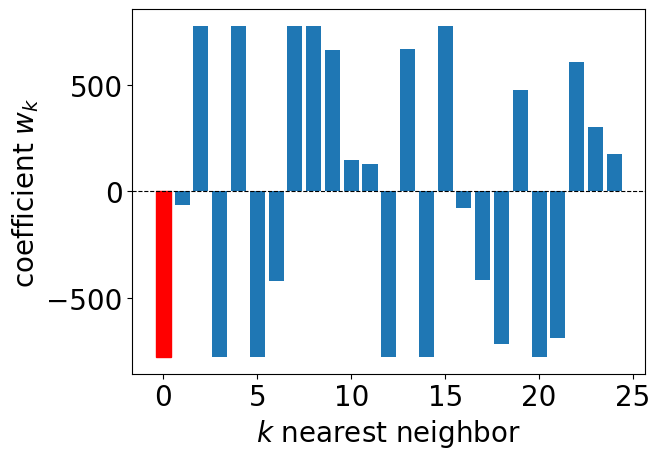

In [27]:
weights = fixed_weights_list[16][1]
plot_weights(weights)